In [1]:
### imports

%load_ext autoreload
%autoreload 2

import os

import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions

In [3]:
# paths for all of the used catalogs

catalogs = "~/Desktop/mpe/fits/catalogs/"
plots_dir = "/Users/bene/Desktop/mpe/plots/"

mawa = catalogs + "mawatari_final.fits"

# creating the mawatari, matched and missed sources catalogs
mawatari = Table.read(mawa)
matched_mask = mawatari["matched_in_reference"] == False
missed = mawatari[matched_mask]

matched = mawatari[~matched_mask]

### Doing the fov plot and the statistics of the found sources

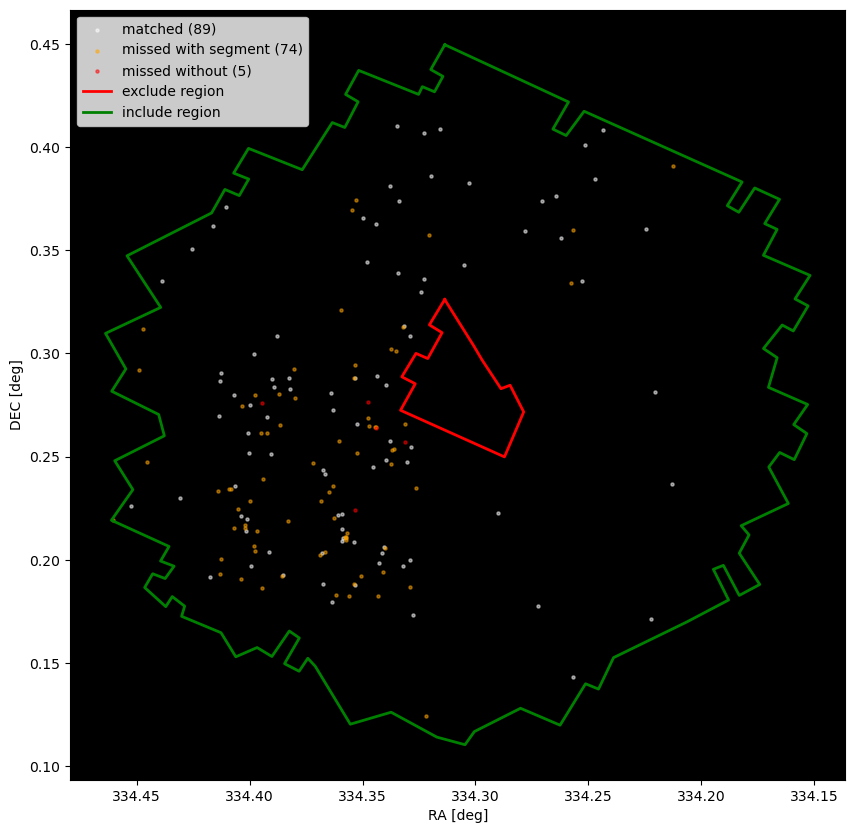

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

regions = Regions.read("/Users/bene/Desktop/mpe/regions/fov.reg", format="ds9")

# Alle Quellen
ax.scatter(matched["vdfi_ra_vdfi"], matched["vdfi_dec_vdfi"], s=5, c="white", alpha=0.5,
           label=f"matched ({len(matched)})")

mask = missed["cube_value"] == 0
mask_ = ~mask

ax.scatter(missed["RA"][mask_], missed["DEC"][mask_], s=5, c="orange",
           alpha=0.5, label=f"missed with segment ({mask_.sum()})")
ax.scatter(missed["RA"][mask], missed["DEC"][mask], s=5, c="red", alpha=0.5,
           label=f"missed without ({mask.sum()})")

# Regionen in WCS (RA/DEC) einzeichnen
r0_sky = regions[0]
r1_sky = regions[1]

vra0, vdec0 = r0_sky.vertices.ra.deg, r0_sky.vertices.dec.deg
vra1, vdec1 = r1_sky.vertices.ra.deg, r1_sky.vertices.dec.deg

ax.plot(np.append(vra0, vra0[0]), np.append(vdec0, vdec0[0]), c="red", lw=2,
        label="exclude region")
ax.plot(np.append(vra1, vra1[0]), np.append(vdec1, vdec1[0]), c="green", lw=2,
        label="include region")

ax.invert_xaxis()

ax.set_xlabel("RA [deg]")
ax.set_ylabel("DEC [deg]")
ax.set_facecolor("black")
ax.legend()
plt.savefig(os.path.join(plots_dir, "Mawatari_map.pdf"))
plt.show()

### Changes to the plot

maybe a second version of the plot or in this plot
- bad regions & Stars 

### Statistics:

In [11]:
match = mawatari["matched_in_reference"] == True
mask = missed["cube_value"] == 0
mask_ = ~mask

print(f"Matched sources: {match.sum()}")
print(f"Missed sources without segment: {mask.sum()}")
print(f"Missed sources with segment: {mask_.sum()}")

Matched sources: 89
Missed sources without segment: 5
Missed sources with segment: 74


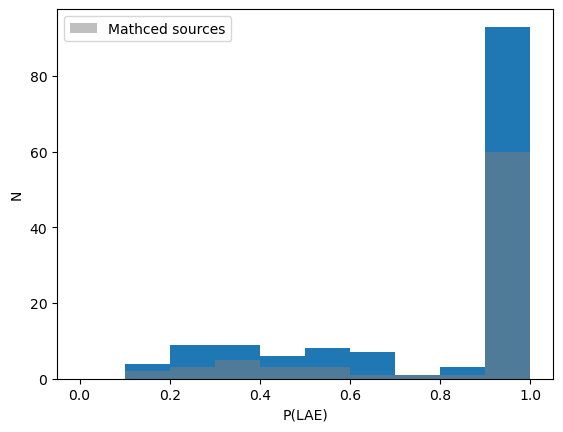

In [21]:
# make a Histogram to see how th distribution of P(LAE) looks like
bins = np.linspace(0, 1, 11)

plt.hist(mawatari["PROB"], bins=bins)
plt.hist(matched["PROB"], bins=bins, color="gray", alpha=0.5,
         label="Mathced sources")
plt.xlabel("P(LAE)")
plt.ylabel("N")
plt.legend()
plt.savefig(os.path.join(plots_dir, "Mawatari_PROB_HIST.pdf"))
plt.show()

# Sources found but P(LAE) < 0.5

Here we identify the sources that were found by our algorithm but they have a probability of less than 50% to be a LAE. 